Parsed transactions: (2540, 6)
  record_type   routing     account  amount sec_code debit_credit_flag
0           6  22200002  1265596978   31123      BOC                 C
1           6  33300003  7626998436   36813      BOC                 D
2           6  22200002  2444483047    5519      BOC                 D
3           6  44400004  2446014505   27414      PPD                 D
4           6  33300003  5446256254   46683      PPD                 D
sec_code
PPD    386
WEB    380
ARC    367
CCD    359
RCK    358
TEL    353
BOC    337
Name: count, dtype: int64
debit_credit_flag
D    1939
C     601
Name: count, dtype: int64
routing
33300003    545
44400004    532
22200002    497
11100001    494
55500005    472
Name: count, dtype: int64


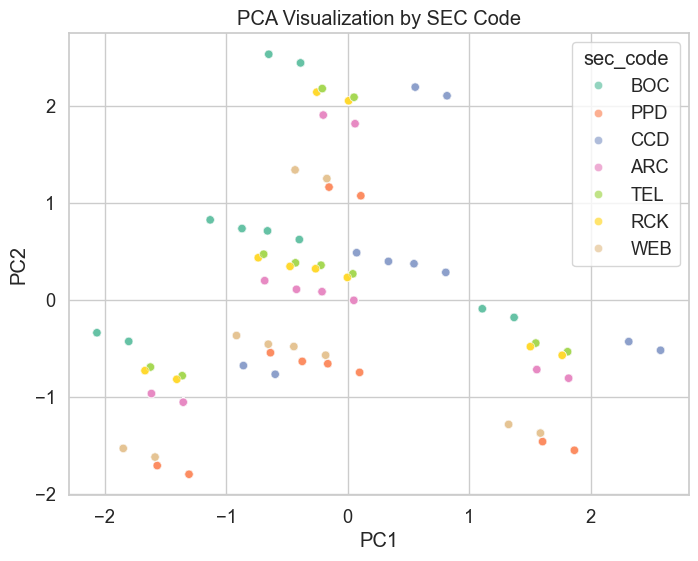

Explained variance ratio: [0.11659514 0.11577801]


C:\Users\ramya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


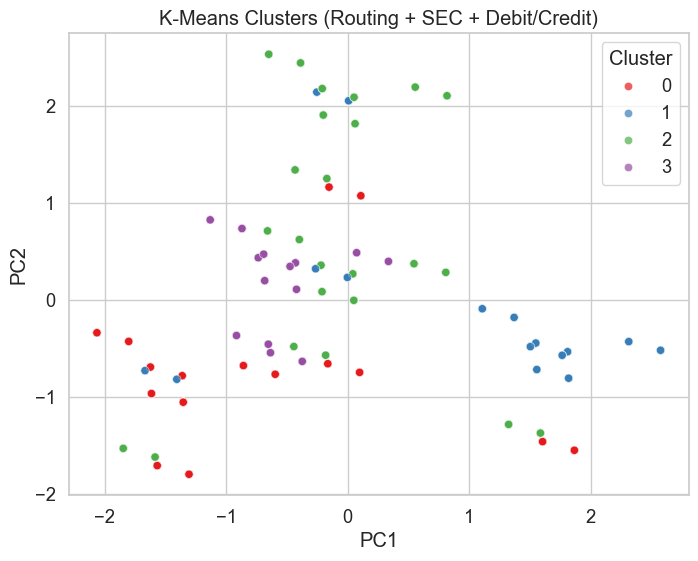

          routing sec_code debit_credit_flag
Cluster                                     
0        44400004      PPD                 D
1        33300003      RCK                 D
2        11100001      WEB                 D
3        55500005      WEB                 D
Classification Report:
               precision    recall  f1-score   support

           C       0.00      0.00      0.00       180
           D       0.76      1.00      0.87       582

    accuracy                           0.76       762
   macro avg       0.38      0.50      0.43       762
weighted avg       0.58      0.76      0.66       762

Confusion Matrix:
 [[  0 180]
 [  0 582]]


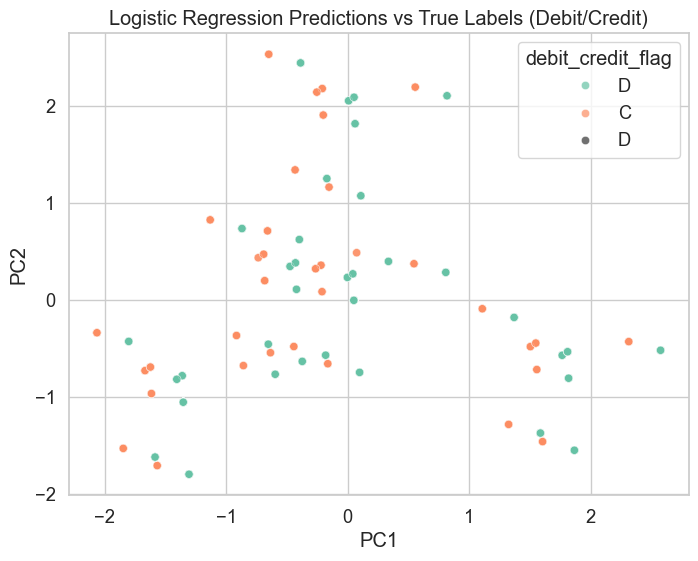

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# 1. Load and Parse Synthetic ACH Files
files = glob.glob("data/*.txt")
records = []

for f in files:
    with open(f, "r") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith("6"):  # transaction records
                record_type = line[0]
                transaction_code = line[1:3]          # "22" credit, "27" debit
                routing = line[3:11]                  # routing number
                account = line[11:28].strip()         # account number
                amount = int(line[28:38])             # cents
                sec_code = line[38:41].strip()        # SEC code (PPD, CCD, WEB, etc.)
                debit_credit_flag = "C" if transaction_code == "22" else "D"
                records.append({
                    "record_type": record_type,
                    "routing": routing,
                    "account": account,
                    "amount": amount,
                    "sec_code": sec_code,
                    "debit_credit_flag": debit_credit_flag
                })

df = pd.DataFrame(records)
print("Parsed transactions:", df.shape)
print(df.head())

# 2. Profiling 
print(df["sec_code"].value_counts())
print(df["debit_credit_flag"].value_counts())
print(df["routing"].value_counts())

#  3. Encode Features for Clustering 
routing_dummies = pd.get_dummies(df["routing"], prefix="routing", drop_first=True)
sec_dummies = pd.get_dummies(df["sec_code"], prefix="sec", drop_first=True)
flag_dummies = pd.get_dummies(df["debit_credit_flag"], prefix="flag", drop_first=True)

X = pd.concat([routing_dummies, sec_dummies, flag_dummies], axis=1)

# 4. Scale and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

df["PC1"] = principal_components[:,0]
df["PC2"] = principal_components[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="sec_code", data=df, palette="Set2", alpha=0.7)
plt.title("PCA Visualization by SEC Code")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

# 5. Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=df, palette="Set1", alpha=0.7)
plt.title("K-Means Clusters (Routing + SEC + Debit/Credit)")
plt.show()

cluster_summary = df.groupby("Cluster")[["routing","sec_code","debit_credit_flag"]].agg(lambda x: x.value_counts().index[0])
print(cluster_summary)

# 6. Logistic Regression (Predict Debit vs Credit)
X_pca = df[["PC1","PC2"]]
y = df["debit_credit_flag"]

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visualization of predictions
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_test["PC1"], y=X_test["PC2"], hue=y_test, style=y_pred, palette="Set2", alpha=0.7)
plt.title("Logistic Regression Predictions vs True Labels (Debit/Credit)")
plt.show()


In [34]:
import os, random, datetime
import pandas as pd

# Assume you already have df with clusters assigned
# Sample a handful of entries from each cluster
samples = df.groupby("Cluster", group_keys=False).sample(n=10)

# NACHA components
def make_file_header():
    return "1" + " " * 93

def make_batch_header(sec_code="PPD"):
    company_name = "CONSOLIDATED".ljust(16)
    today = datetime.date.today().strftime("%y%m%d")
    return "5" + sec_code.ljust(3) + company_name + today.ljust(6) + " " * 69

def make_entry_detail(row):
    record_type = "6"
    # Use routing, account, amount, sec_code, debit_credit_flag from sample
    transaction_code = "22" if row["debit_credit_flag"] == "C" else "27"
    routing = row["routing"]
    account = str(random.randint(1000000000,9999999999)).ljust(17)
    amount = str(row["amount"]).zfill(10)
    sec_code = row["sec_code"]
    debit_credit_flag = row["debit_credit_flag"]
    line = (
        record_type
        + transaction_code
        + routing
        + account
        + amount
        + sec_code.ljust(3)
        + debit_credit_flag
    )
    return line.ljust(96)

def make_batch_control(entry_count, total_amount):
    return "8" + str(entry_count).zfill(6) + str(total_amount).zfill(12) + " " * 74

def make_file_control(batch_count, entry_count, total_amount):
    return "9" + str(batch_count).zfill(6) + str(entry_count).zfill(8) + str(total_amount).zfill(12) + " " * 68

# Build consolidated file
filename = "data/consolidated_ach.txt"
entries = []
total_amount = 0

with open(filename, "w") as f:
    f.write(make_file_header() + "\n")
    f.write(make_batch_header(sec_code="PPD") + "\n")
    for _, row in samples.iterrows():
        entry = make_entry_detail(row)
        f.write(entry + "\n")
        entries.append(entry)
        total_amount += int(row["amount"])
    f.write(make_batch_control(len(entries), total_amount) + "\n")
    f.write(make_file_control(1, len(entries), total_amount) + "\n")

print(f"Created consolidated ACH file with {len(entries)} entries, total amount {total_amount}")


Created consolidated ACH file with 40 entries, total amount 954012


Shape: (40, 9)

Head:
      record_type   routing     account  amount sec_code debit_credit_flag  \
1641           6  22200002  8681279905   40749      CCD                 D   
1724           6  22200002  5301985081    4602      ARC                 D   
249            6  22200002  7060829535     875      TEL                 D   
2334           6  22200002  6420655682   21716      PPD                 D   
2145           6  22200002  8668168560   45495      PPD                 D   

           PC1       PC2  Cluster  
1641  0.425356  2.009725        0  
1724 -0.284517  1.692665        0  
249  -0.276123  1.987352        0  
2334 -0.116709  0.784235        0  
2145 -0.116709  0.784235        0  

Summary:
        record_type   routing     account       amount sec_code  \
count           40        40          40     40.00000       40   
unique           1         5          40          NaN        7   
top              6  33300003  8681279905          NaN      TEL   
freq            40     

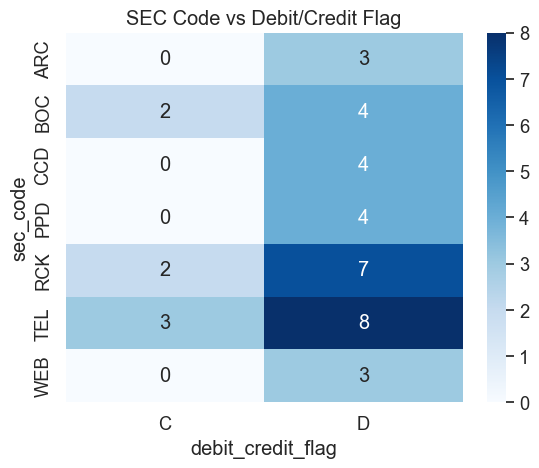


Cluster Summary:
 Cluster  sec_code  debit_credit_flag
0        PPD       D                    4
         CCD       D                    2
         TEL       D                    2
         ARC       D                    1
         TEL       C                    1
1        BOC       D                    4
         TEL       D                    3
         BOC       C                    2
         CCD       D                    1
2        WEB       D                    3
         ARC       D                    2
         TEL       C                    2
                   D                    2
         CCD       D                    1
3        RCK       D                    7
                   C                    2
         TEL       D                    1
Name: count, dtype: int64

Totals by SEC + Debit/Credit:
   sec_code debit_credit_flag  amount
0      ARC                 D   58172
1      BOC                 C   21470
2      BOC                 D  107826
3      CCD              

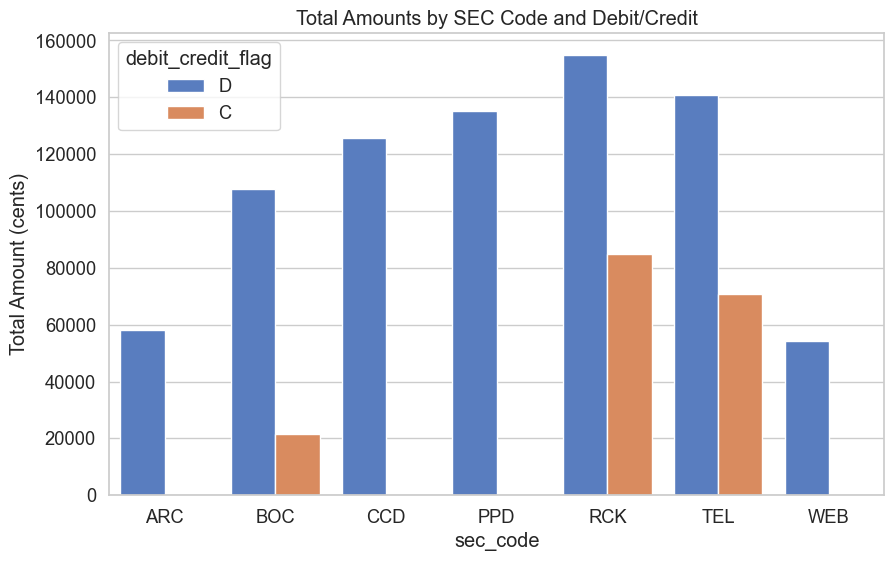

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(samples)  

# -------------------------------
# 1. Basic Profiling
# -------------------------------
print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nSummary:\n", df.describe(include="all"))

# -------------------------------
# 2. Distribution Analysis
# -------------------------------
print("\nSEC Code Counts:\n", df['sec_code'].value_counts())
print("\nDebit/Credit Counts:\n", df['debit_credit_flag'].value_counts())
print("\nRouting Counts:\n", df['routing'].value_counts())

# -------------------------------
# 3. Cross-tab Analysis
# -------------------------------
ct = pd.crosstab(df['sec_code'], df['debit_credit_flag'])
print("\nCross-tab SEC vs Debit/Credit:\n", ct)

sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("SEC Code vs Debit/Credit Flag")
plt.show()

# -------------------------------
# 4. Cluster Validation
# -------------------------------
cluster_summary = df.groupby("Cluster")[["sec_code","debit_credit_flag"]].value_counts()
print("\nCluster Summary:\n", cluster_summary)

# -------------------------------
# 5. Totals by Category
# -------------------------------
totals = df.groupby(["sec_code","debit_credit_flag"])['amount'].sum().reset_index()
print("\nTotals by SEC + Debit/Credit:\n", totals)

plt.figure(figsize=(10,6))
sns.barplot(data=totals, x="sec_code", y="amount", hue="debit_credit_flag")
plt.title("Total Amounts by SEC Code and Debit/Credit")
plt.ylabel("Total Amount (cents)")
plt.show()
